In [1]:
from pypokerengine.engine.hand_evaluator import HandEvaluator
from pypokerengine.engine.card import Card

In [10]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open("results.json", "r", encoding="utf-8") as f:
    data = json.load(f)

records = []

# battles -> players -> opponent_profile_history
for battle_id, battle in enumerate(data.get("battles", [])):
    players = battle.get("players", {})
    for player_name, player_stats in players.items():
        opp_hist = player_stats.get("opponent_profile_history", {})
        
        # opp_hist: { "name": [ { "round": 1, "profile": {...} }, ... ] }
        for opp_name, history_list in opp_hist.items():
            for entry in history_list:
                rnd = entry.get("round")
                profile = entry.get("profile", {})
                traits = profile.get("Traits", {})
                
                records.append({
                    "battle_id": battle_id,
                    "player": player_name,      
                    "opponent": opp_name,       
                    "round": rnd,
                    "RiskTolerance": traits.get("RiskTolerance"),
                    "Aggressiveness": traits.get("Aggressiveness"),
                    "BluffFrequency": traits.get("BluffFrequency"),
                    "CallingStationTendency": traits.get("CallingStationTendency"),
                    "ShowdownPropensity": traits.get("ShowdownPropensity"),
                })

df_profiles = pd.DataFrame(records)

player_to_llm = {
    "Alex Chen": 'GPT-4.1-mini',
    "Sarah Johnson": 'Llama-4-Maverick',
    "Emily Zhang": 'DeepSeek-V3.2',
    "Jessica Liu": 'Gemini-2.5-Flash-Lite',
    'Robert Garcia': 'Qwen-3-32B',
    'Niko Grey': 'Grok-3-Mini',
    "Noah Kim": "loose passive bot",
    "Ava Park": "loose aggressive bot",
    "Noah Blake": "Maniac",
    "Lily Grant": "TightPassive",
    "Jade Park": "TightAggressive",
}


df_profiles = df_profiles.copy()
df_profiles["llm"] = df_profiles["player"].map(player_to_llm)

# 类型和排序
df_profiles["round"] = pd.to_numeric(df_profiles["round"], errors="coerce")
df_profiles = df_profiles.sort_values(["llm", "opponent", "round"]).reset_index(drop=True)

df_profiles.head()


,battle_id,player,opponent,round,RiskTolerance,Aggressiveness,BluffFrequency,CallingStationTendency,ShowdownPropensity,llm
0,0,Emily Zhang,Alex Chen,1,0.55,0.45,0.45,0.55,0.45,DeepSeek-V3.2
1,1,Emily Zhang,Alex Chen,1,0.50,0.50,0.50,0.50,0.55,DeepSeek-V3.2
2,2,Emily Zhang,Alex Chen,1,0.50,0.50,0.50,0.55,0.55,DeepSeek-V3.2
3,3,Emily Zhang,Alex Chen,1,0.50,0.50,0.50,0.50,0.55,DeepSeek-V3.2
4,4,Emily Zhang,Alex Chen,1,0.45,0.45,0.45,0.55,0.55,DeepSeek-V3.2


In [11]:
#bot_names = ["LAG Bot A", "TP Bot B"]
bot_names = []
df_profiles_clean = df_profiles[~df_profiles["opponent"].isin(bot_names)].copy()
df_profiles_clean.head()


,battle_id,player,opponent,round,RiskTolerance,Aggressiveness,BluffFrequency,CallingStationTendency,ShowdownPropensity,llm
0,0,Emily Zhang,Alex Chen,1,0.55,0.45,0.45,0.55,0.45,DeepSeek-V3.2
1,1,Emily Zhang,Alex Chen,1,0.50,0.50,0.50,0.50,0.55,DeepSeek-V3.2
2,2,Emily Zhang,Alex Chen,1,0.50,0.50,0.50,0.55,0.55,DeepSeek-V3.2
3,3,Emily Zhang,Alex Chen,1,0.50,0.50,0.50,0.50,0.55,DeepSeek-V3.2
4,4,Emily Zhang,Alex Chen,1,0.45,0.45,0.45,0.55,0.55,DeepSeek-V3.2


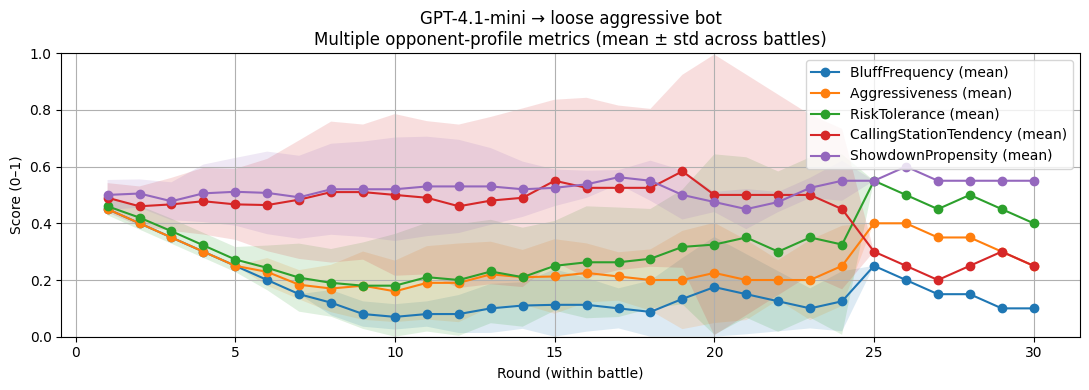

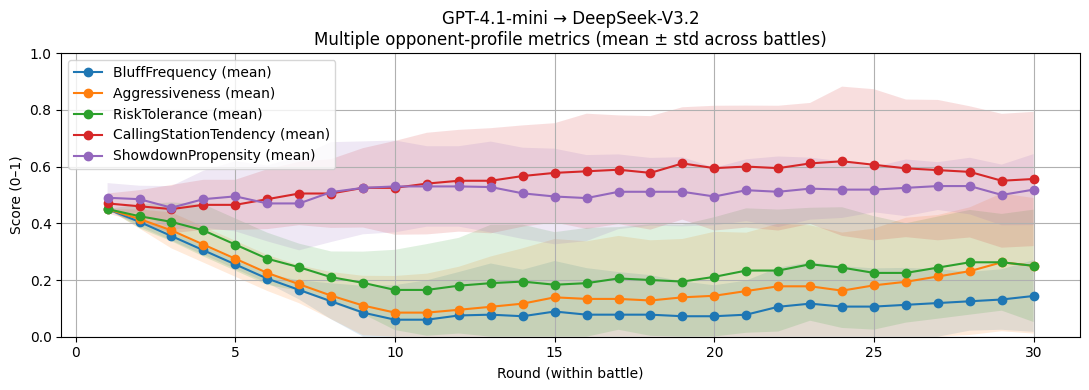

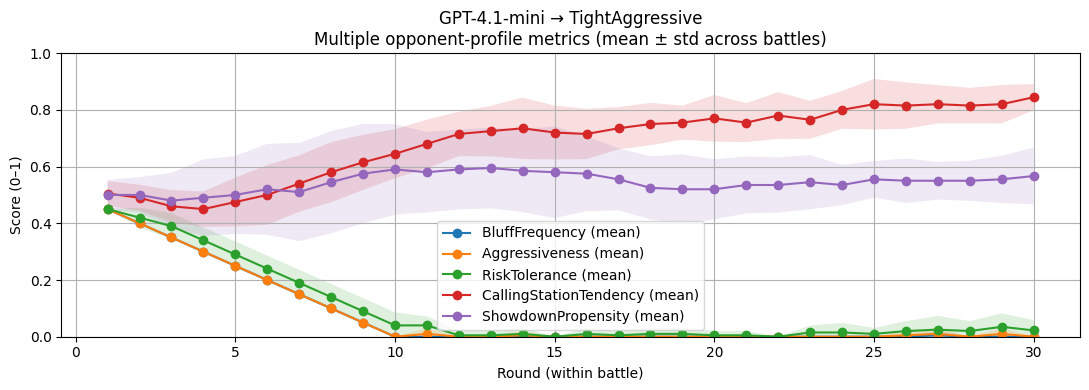

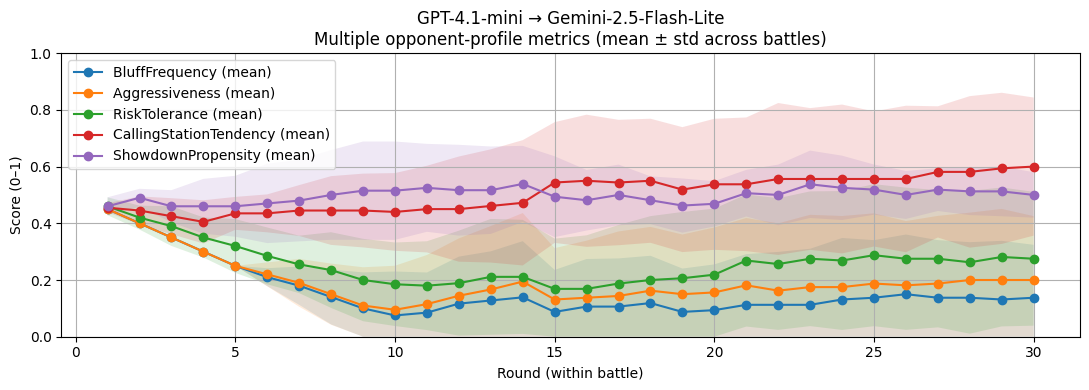

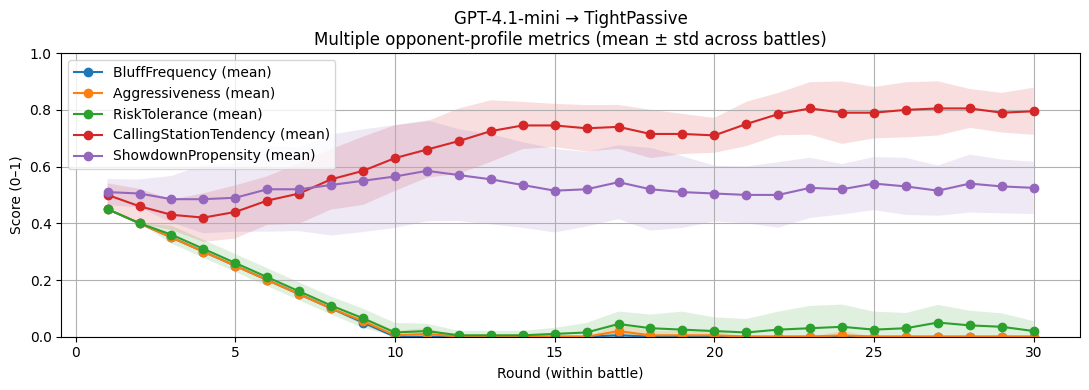

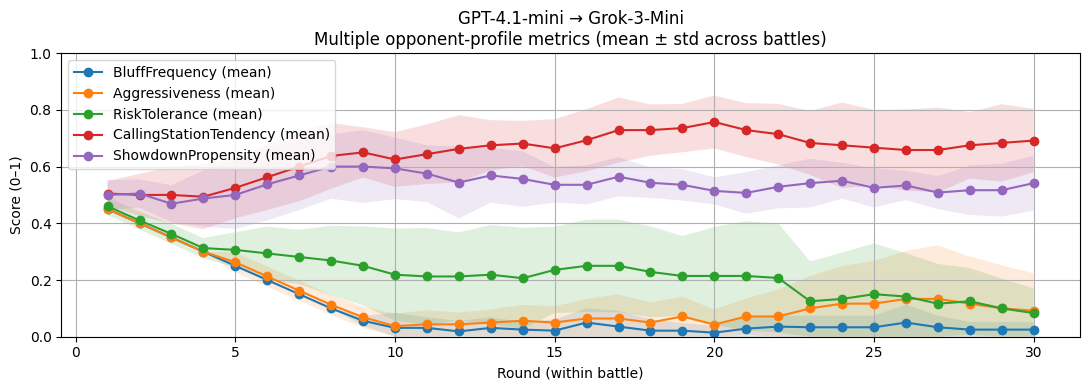

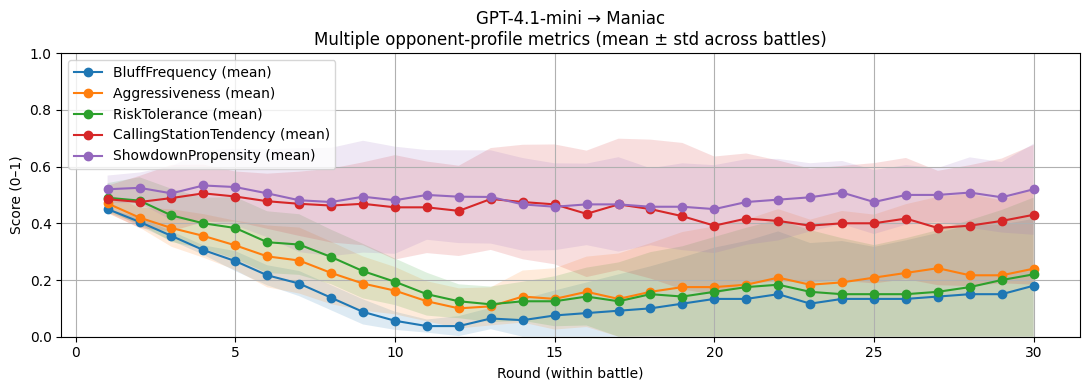

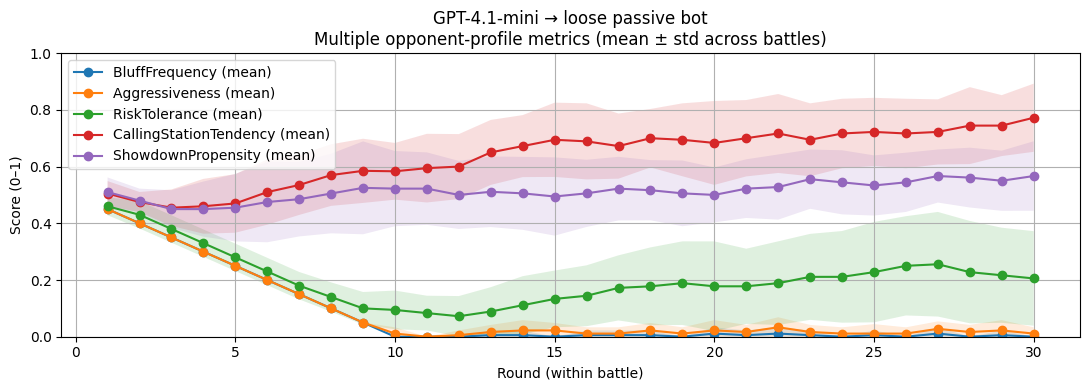

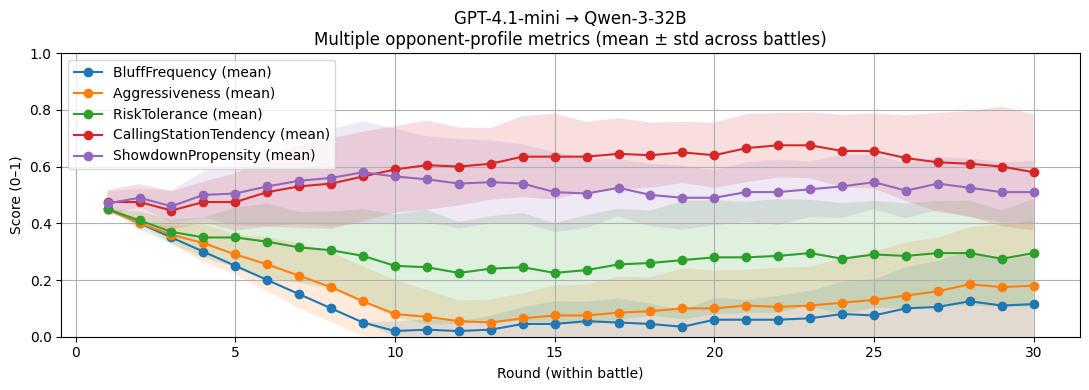

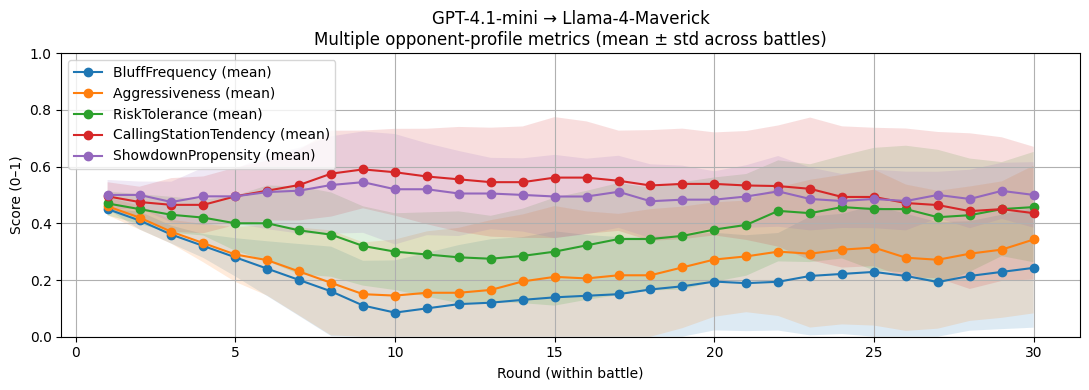

In [13]:
import numpy as np
import matplotlib.pyplot as plt

focus_llm = "GPT-4.1-mini"
metrics = ["BluffFrequency", "Aggressiveness", "RiskTolerance","CallingStationTendency","ShowdownPropensity"]

sub_all = df_profiles[
    (df_profiles["llm"] == focus_llm)
].dropna(subset=["round", "battle_id", "opponent"])

for focus_opp, sub in sub_all.groupby("opponent"):

    opp_display = player_to_llm.get(focus_opp, focus_opp)

    plt.figure(figsize=(11,4))
    plotted_any = False

    for metric in metrics:
        tmp = sub.dropna(subset=[metric])
        if tmp.empty:
            continue

        agg = (tmp.groupby("round")[metric]
                 .agg(mean="mean", std="std", n="count")
                 .reset_index())

        if len(agg) < 2:
            continue

        x = agg["round"].to_numpy()
        m = agg["mean"].to_numpy()
        s = agg["std"].fillna(0).to_numpy()

        plt.plot(x, m, marker="o", label=f"{metric} (mean)")
        plt.fill_between(
            x,
            np.clip(m - s, 0, 1),
            np.clip(m + s, 0, 1),
            alpha=0.15
        )
        plotted_any = True

    if not plotted_any:
        plt.close()
        continue

    plt.ylim(0, 1)
    plt.xlabel("Round (within battle)")
    plt.ylabel("Score (0–1)")
    plt.title(
        f"{focus_llm} → {opp_display}\n"
        "Multiple opponent-profile metrics (mean ± std across battles)"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



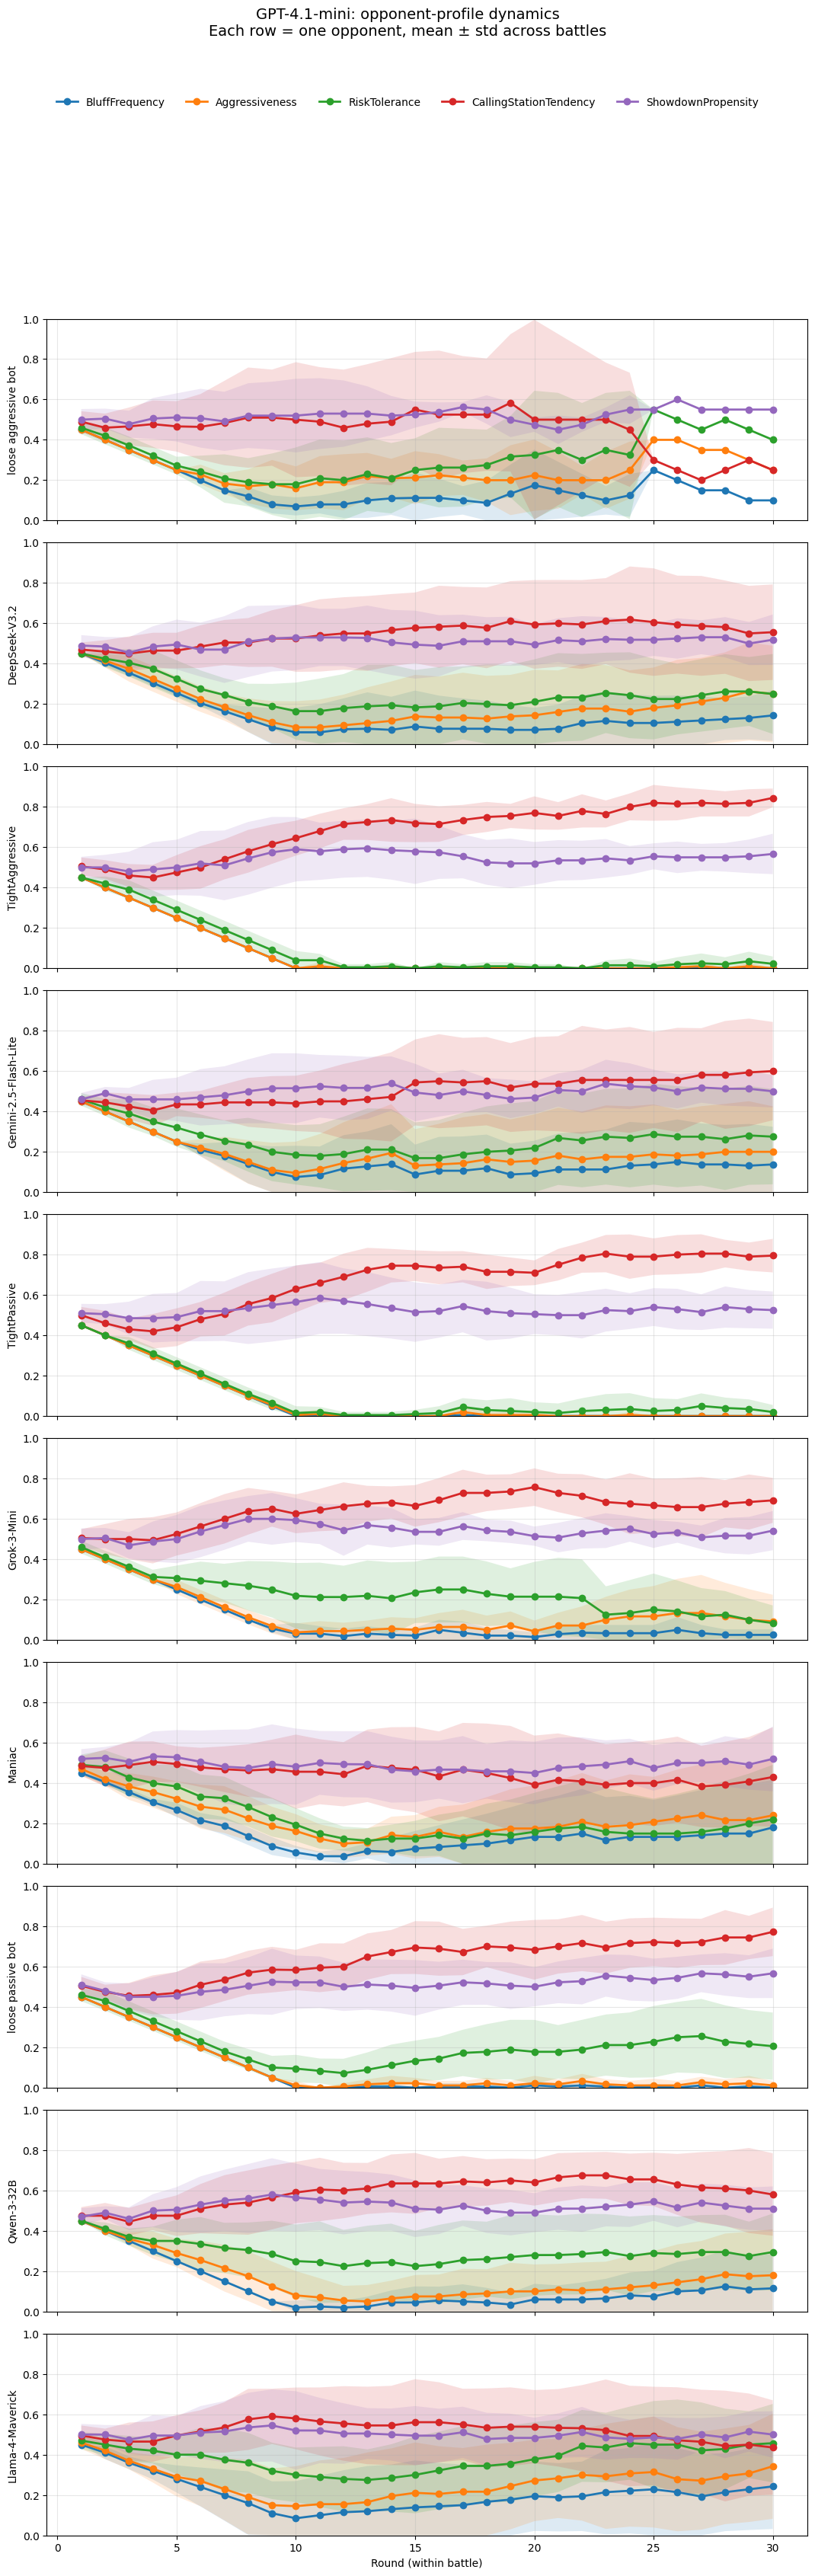

In [14]:
import numpy as np
import matplotlib.pyplot as plt

focus_llm = "GPT-4.1-mini"
metrics = [
    "BluffFrequency",
    "Aggressiveness",
    "RiskTolerance",
    "CallingStationTendency",
    "ShowdownPropensity"
]

sub_all = df_profiles[
    (df_profiles["llm"] == focus_llm)
].dropna(subset=["round", "battle_id", "opponent"])

opponents = list(sub_all["opponent"].unique())
n_opps = len(opponents)

fig, axes = plt.subplots(
    nrows=n_opps,
    ncols=1,
    figsize=(12, 3.5 * n_opps),
    sharex=True
)

if n_opps == 1:
    axes = [axes]

for ax, focus_opp in zip(axes, opponents):

    sub = sub_all[sub_all["opponent"] == focus_opp]
    opp_display = player_to_llm.get(focus_opp, focus_opp)

    plotted_any = False

    for metric in metrics:
        tmp = sub.dropna(subset=[metric])
        if tmp.empty:
            continue

        agg = (
            tmp.groupby("round")[metric]
               .agg(mean="mean", std="std", n="count")
               .reset_index()
        )

        if len(agg) < 2:
            continue

        x = agg["round"].to_numpy()
        m = agg["mean"].to_numpy()
        s = agg["std"].fillna(0).to_numpy()

        ax.plot(
            x, m,
            marker="o",
            linewidth=2,
            label=metric
        )

        ax.fill_between(
            x,
            np.clip(m - s, 0, 1),
            np.clip(m + s, 0, 1),
            alpha=0.15
        )

        plotted_any = True

    if not plotted_any:
        ax.set_visible(False)
        continue

    ax.set_ylim(0, 1)
    ax.set_ylabel(opp_display)
    ax.grid(True, alpha=0.3)


axes[-1].set_xlabel("Round (within battle)")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=5,
    frameon=False,
    fontsize=10
)

fig.suptitle(
    f"{focus_llm}: opponent-profile dynamics\n"
    "Each row = one opponent, mean ± std across battles",
    fontsize=14,
    y=0.995
)

plt.tight_layout(rect=[0.05, 0.03, 0.95, 0.90])
plt.show()

